# Did the email campaign actually work?

**Question.** A retailer emailed some of its customers. Did the email *cause* more of them to visit the website, and by how much?

**Why it's hard.** In real life, marketing teams don't email customers at random. They target their best customers, the ones who were already likely to visit. Comparing emailed with non-emailed customers then mixes up the effect of the email with the effect of *who was chosen*.

**How this project checks itself.** The [Hillstrom MineThatData dataset](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html) comes from a *randomised* experiment on 64,000 customers, so it contains the true answer. I use it twice:

1. On the full randomised data, to get the ground-truth effect.
2. On a realistic *targeted* version I create from it, where high-value customers were more likely to be emailed. Here I compare a naive analysis with modern causal inference methods (IPW, AIPW and TMLE) and see which ones recover the truth.

In [1]:
import sys; sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from causal import load_hillstrom, make_features, simulate_targeting, estimate_all, naive
from plots import apply_style, balance_plot, forest_plot, simulation_plot, heterogeneity_plot

apply_style()
df = load_hillstrom("../data/hillstrom.csv")
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treated
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0,1
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0,1
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,1


## 1. The ground truth from the randomised experiment

Customers were randomly split three ways: a men's merchandise email, a women's merchandise email, or no email. I treat *any* email as the treatment and a website visit in the following two weeks as the outcome.

In [2]:
summary = df.groupby("segment")[["visit", "conversion", "spend"]].mean()
summary["customers"] = df["segment"].value_counts()
display(summary.round(3))

truth = naive(df["treated"], df["visit"])
print(f"True effect of an email on visit rate: {truth['estimate']*100:.1f} percentage points "
      f"(95% CI {truth['lower']*100:.1f} to {truth['upper']*100:.1f})")
print(f"Visit rate without email: {df.loc[df.treated==0,'visit'].mean()*100:.1f}%, "
      f"so the email lifts visits by about {truth['estimate']/df.loc[df.treated==0,'visit'].mean()*100:.0f}% in relative terms")

,visit,conversion,spend,customers
segment,,,,
Mens E-Mail,0.183,0.013,1.423,21307
No E-Mail,0.106,0.006,0.653,21306
Womens E-Mail,0.151,0.009,1.077,21387


True effect of an email on visit rate: 6.1 percentage points (95% CI 5.5 to 6.6)
Visit rate without email: 10.6%, so the email lifts visits by about 57% in relative terms


## 2. The realistic version: a targeted campaign

Now I simulate what the data would look like if the marketing team had *chosen* who to email, favouring customers who spent more last year, bought recently, and shop across channels. The function `simulate_targeting()` keeps a random third of customers, but within that third the chance of having been emailed depends on those characteristics. The true effect is unchanged (see the docstring in `src/causal.py` for why), so the experiment's answer is still the right one.

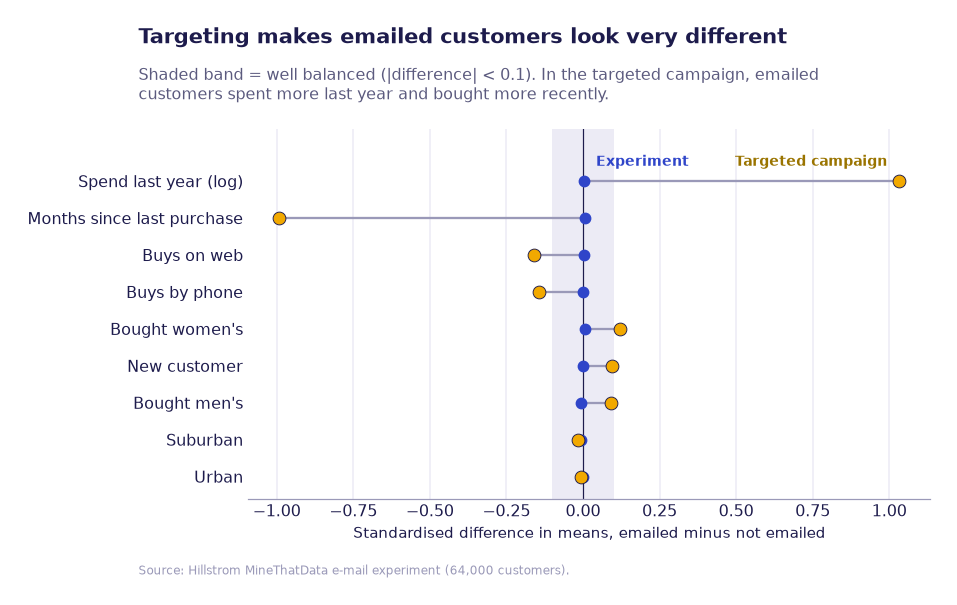

In [3]:
obs = simulate_targeting(df, seed=7)
X = make_features(obs)

def smd(x, a):
    return (x[a == 1].mean() - x[a == 0].mean()) / np.sqrt((x[a == 1].var() + x[a == 0].var()) / 2)

balance = pd.DataFrame({
    "Randomised experiment": [smd(make_features(df)[c], df.treated) for c in X.columns],
    "Targeted campaign": [smd(X[c], obs.treated) for c in X.columns]}, index=X.columns)
nice = {"recency": "Months since last purchase", "log_history": "Spend last year (log)", "mens": "Bought men's",
        "womens": "Bought women's", "newbie": "New customer", "zip_Surburban": "Suburban", "zip_Urban": "Urban",
        "channel_Phone": "Buys by phone", "channel_Web": "Buys on web"}
balance = balance.rename(index=nice)

balance_plot(balance, "../figures/balance.png");


In the experiment every difference is close to zero (the shaded band marks the usual ±0.1 threshold). In the targeted campaign, emailed customers spent far more last year and bought more recently. Those customers would visit more often anyway, so a naive comparison will overstate what the email did.

## 3. Naive analysis versus causal inference

I compare five estimators. All adjusted methods use the same customer features, with gradient-boosted models fitted using 5-fold cross-fitting.

| Estimator | Idea |
|---|---|
| Naive comparison | Visit rate of emailed minus non-emailed customers |
| Outcome regression | Predict each customer's visit probability with and without an email, and average the difference |
| IPW | Reweight customers by the inverse of their chance of being emailed, so both groups resemble the whole customer base |
| AIPW | Combines both models; correct if *either* one is right (doubly robust) |
| TMLE | Also doubly robust; nudges the outcome model so the final answer is both efficient and stays within valid probabilities |

,estimate (pp),se (pp),lower (pp),upper (pp)
Naive comparison,10.25,0.47,9.33,11.16
Outcome regression,6.46,NaN,NaN,NaN
IPW,7.40,0.65,6.14,8.67
AIPW,7.18,0.64,5.93,8.42
TMLE,7.20,0.64,5.96,8.45


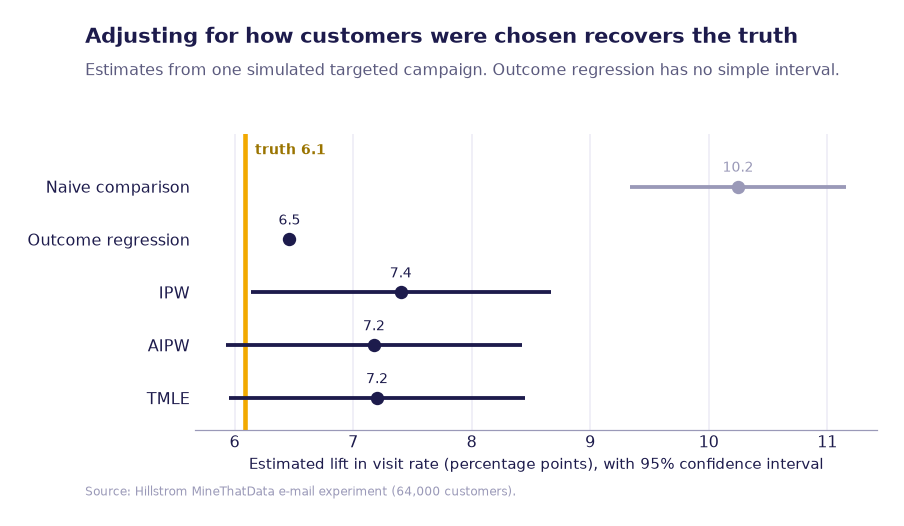

In [4]:
res = estimate_all(obs, seed=7)
display((res * 100).round(2).rename(columns=lambda c: c + " (pp)"))

order = ["Naive comparison", "Outcome regression", "IPW", "AIPW", "TMLE"]
forest_plot(res, truth["estimate"], order, "../figures/single_run.png");


## 4. Is that a fluke? Repeating it 100 times

One dataset can be lucky or unlucky, so `src/run_sim.py` repeats the whole exercise on 100 different targeted campaigns. For each method I check two things:

- **Bias:** on average, does it land on the true effect?
- **Coverage:** does its 95% confidence interval contain the truth about 95% of the time? A method can have little bias yet still be overconfident.

,Average estimate (pp),Bias (pp),Spread across runs (pp),95% CI coverage
estimator,,,,
Naive comparison,9.80,3.71,0.38,0%
Outcome regression,5.57,-0.51,0.56,n/a
IPW,6.20,0.11,0.68,95%
AIPW,6.08,-0.01,0.69,95%
TMLE,6.07,-0.01,0.69,95%


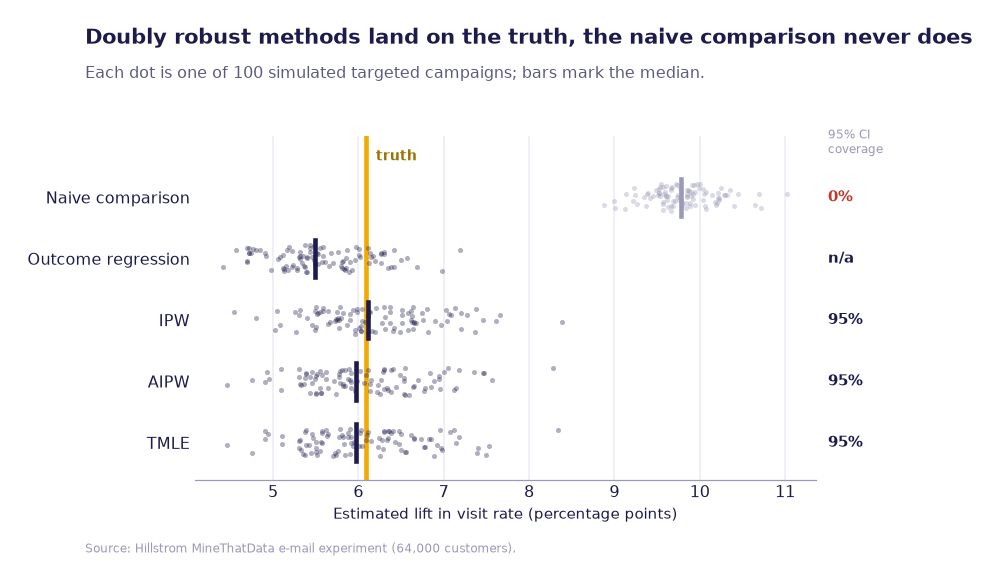

In [5]:
sim = pd.read_csv("../results/simulation_results.csv")
sim["covered"] = (sim.lower <= sim.truth) & (sim.truth <= sim.upper)
table = sim.groupby("estimator").agg(
    mean_estimate=("estimate", "mean"), bias=("estimate", lambda e: e.mean() - sim.truth.iloc[0]),
    spread=("estimate", "std"), coverage=("covered", "mean")).reindex(order)
table.loc["Outcome regression", "coverage"] = np.nan
display(pd.DataFrame({
    "Average estimate (pp)": (table.mean_estimate * 100).round(2),
    "Bias (pp)": (table.bias * 100).round(2),
    "Spread across runs (pp)": (table.spread * 100).round(2),
    "95% CI coverage": table.coverage.map(lambda c: "n/a" if pd.isna(c) else f"{c:.0%}")}))

simulation_plot(sim, truth["estimate"], order, table.coverage, "../figures/simulation.png");


## 5. Which email should each customer get?

Knowing the *average* effect is useful, but the business decision is who gets which email. Because the full dataset is a randomised experiment, I can compare each email with no email within customer groups, with no adjustment needed. The clearest split is by what customers bought last year.

,shopper,email,customers,lift (pp),95% CI low,95% CI high
0,Bought both,Men's email,6448,13.4,10.9,16.0
1,Bought both,Women's email,6448,7.1,4.6,9.6
2,Bought men's only,Men's email,28818,6.9,6.0,7.9
3,Bought men's only,Women's email,28818,1.1,0.2,2.0
4,Bought women's only,Men's email,28734,7.1,6.1,8.0
5,Bought women's only,Women's email,28734,7.4,6.4,8.4


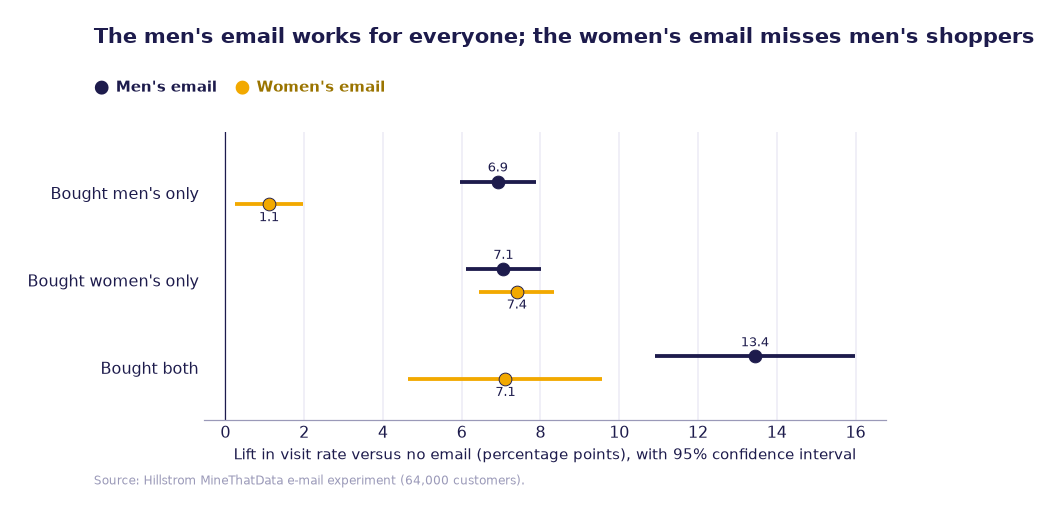

In [6]:
df["shopper"] = np.select([(df.mens == 1) & (df.womens == 0), (df.mens == 0) & (df.womens == 1)],
                          ["Bought men's only", "Bought women's only"], "Bought both")
rows = []
for shopper, g in df.groupby("shopper"):
    for email in ["Mens E-Mail", "Womens E-Mail"]:
        s = g[g.segment.isin([email, "No E-Mail"])]
        rows.append({"shopper": shopper, "email": email.replace(" E-Mail", "'s email").replace("Mens", "Men").replace("Womens", "Women"),
                     "customers": len(g), **naive((s.segment == email).astype(int), s.visit)})
hte = pd.DataFrame(rows)
display(hte.assign(**{c: (hte[c] * 100).round(1) for c in ["estimate", "lower", "upper"]})
           .drop(columns="se").rename(columns={"estimate": "lift (pp)", "lower": "95% CI low", "upper": "95% CI high"}))

groups = ["Bought men's only", "Bought women's only", "Bought both"]
heterogeneity_plot(hte, groups, "../figures/who_responds.png");


The men's merchandise email lifts visits by about 7 points for every group, and by about 13 points for customers who buy both lines. The women's email works as well as the men's for women's shoppers, but barely moves customers who only buy men's products (about 1 point). **The men's email is at least as effective as the women's email in every group, so it is the better default, and the women's email should not go to men's-only shoppers.**

## 6. Conclusions

- **The email works.** In the randomised experiment it raised the two-week visit rate by about 6 percentage points, a relative lift of more than 50%.
- **Naive analysis of targeted campaigns badly overstates the impact.** When the best customers are the ones who get emailed, simply comparing groups attributes their natural loyalty to the email and exaggerates the lift substantially.
- **Causal inference methods recover the truth.** IPW, AIPW and TMLE land close to the experimental answer on average. The doubly robust methods (AIPW, TMLE) are the most stable, and their confidence intervals are close to honest.
- **Which email matters.** The women's email is almost wasted on customers who only buy men's products, while the men's email works across the board (section 5).

**Limitations.** This works because every factor that drove targeting is in the data. In a real campaign, if targeting used information the analyst can't see, no adjustment method can fully fix it, and a sensitivity analysis or a holdout test would be the next step. The simulated targeting rule is also deliberately simple.

*Methods and code: `src/causal.py`. All estimators, including TMLE, are implemented from scratch rather than taken from a library.*